**Import Libraries**

In [68]:
import yfinance as yf

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

In [70]:
data = yf.download('Gold',
                   start='2015-01-01',
                   end='2026-07-18',
                   progress=False)

In [71]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOLD,GOLD,GOLD,GOLD,GOLD
Date,,,,,
2015-01-02,3.532226,3.542855,3.475541,3.475541,4200
2015-01-05,3.532226,3.532226,3.422398,3.482626,20400
2015-01-06,3.404684,3.521599,3.394056,3.521599,13200
2015-01-07,3.525141,3.532227,3.404684,3.404684,11400
2015-01-08,3.450741,3.471998,3.450741,3.471998,2000


In [72]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,GOLD,GOLD,GOLD,GOLD,GOLD
Date,,,,,
2026-07-13,38.040001,40.200001,37.930000,39.400002,483600
2026-07-14,39.070000,39.285000,38.389999,38.834999,420000
2026-07-15,39.560001,39.790001,38.680000,39.049999,299700
2026-07-16,38.680000,39.110001,38.259998,38.770000,587100
2026-07-17,38.310001,38.930000,37.799999,38.200001,355000


In [73]:
data['Return'] = data['Close'].pct_change() * 100           # New Column contains percentage change in the stock price from one day to next
                                                            # its calculated as ((Today's Price - Yesturday's Price) / Yesturday's Price) x 100

In [74]:
data['Lagged Return'] = data.Return.shift()           # New column that moves every value down by one

In [75]:
data.dropna(inplace=True)           # Dropping all NaNs values

In [76]:
train = data['2015':'2024']            # Training data is taken from 2015 to 2024 for model training
test = data['2025':'2026']             # Testing data is taken from 2025 to 2026 for model training

In [77]:
x_train = train['Lagged Return'].to_frame()       # Yesturday's Return (feature) for train set
y_train = train['Return']                         # Today's Return (Target) for train set
x_test = test['Lagged Return'].to_frame()         # Similar for test set
y_test = test['Return']                           # Similar for test set

In [78]:
# Model Training
model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)

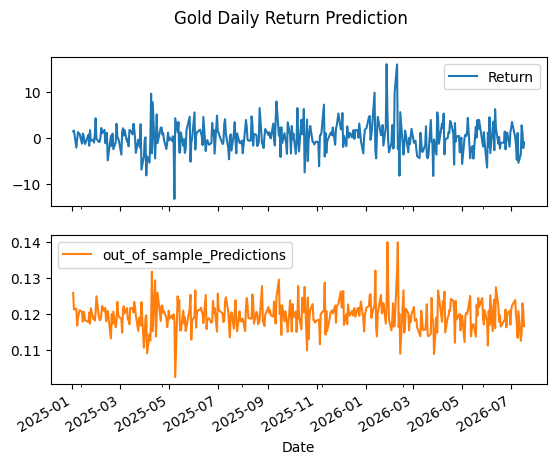

In [79]:
out_of_sample_results = y_test.to_frame()      # creating a dataframe to compare actual and predicted returns
out_of_sample_results['out_of_sample_Predictions'] = predictions     # Adding predicted values to the dataframe
out_of_sample_results.plot(subplots=True, title='Gold Daily Return Prediction')
plt.show()

**Prediction**

In [80]:
# Yesterday's return (%)
new_return = pd.DataFrame([[1.8]], columns=["Lagged Return"])

prediction = model.predict(new_return)

print(f'Predicted Todays Return: {prediction[0]:.2f}%')

Predicted Todays Return: 0.12%


# **Gold Price Prediction**
## **Project Summary**

This project demonstrates a **Time Series Prediction** approach using **Linear Regression** to predict the **daily percentage return of Gold prices** based on the previous day's return. Instead of forecasting the actual gold price, the model learns the relationship between consecutive daily returns to estimate how the market may perform on the next trading day.

## **Dataset Overview**

| Feature | Description |
|----------|-------------|
| Date | Trading date of the Gold asset |
| Open | Opening price of Gold for the day |
| High | Highest price reached during the day |
| Low | Lowest price reached during the day |
| Close | Closing price of Gold for the day |
| Volume | Number of units traded during the day |
| Return | Daily percentage change in the closing price |
| Lagged Return | Previous day's percentage return (used as the input feature) |

## **Project Workflow**

Historical Gold price data was downloaded from **Yahoo Finance** covering the period from **2015 to 2026**. After loading the dataset, two additional features were created: **Return**, which represents the daily percentage change in the closing price, and **Lagged Return**, which stores the previous day's return. Since these calculations introduce missing values in the first row, they were removed before training the model.

Unlike traditional machine learning projects, the data was split **chronologically** rather than randomly to preserve the time sequence. Data from **2015–2024** was used for training, while **2025–2026** was reserved for testing. The model was trained using **Lagged Return** as the independent feature (**X**) and **Return** as the target variable (**Y**).

After training, the model predicted the daily returns for the testing period. The actual returns and predicted returns were plotted together to visually compare the model's performance over time. Finally, the trained model was used to predict the expected return for a new user-provided previous-day return value.

## **Model Used**

- **Algorithm:** Linear Regression
- **Feature (X):** Lagged Return (Previous Day's Return)
- **Target (Y):** Return (Current Day's Return)

## **Prediction**

The trained model can estimate the **current day's expected return** by taking the **previous day's return** as input. For example, when a previous day's return of **1.80%** is provided, the model predicts the corresponding return for the next trading day.

## **Conclusion**

This project introduces the fundamentals of **time series forecasting** by showing how historical financial data can be transformed into supervised learning data using **lag features**. Although the model uses only a single predictor, it demonstrates the basic workflow of preparing sequential data, training a regression model, and generating predictions for future market returns.